In [1]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, AveragePooling2D

In [4]:
from keras.datasets import mnist

In [5]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

## Le Model

In [7]:
model = Sequential()
# in LeNET model input shape is 32x32 but our dataset image size is (28,28) that's why i take  this size but originally the size is (32,32)

model.add(Conv2D(6, kernel_size = (5,5), padding= 'valid', activation= 'tanh', input_shape = (28, 28 ,1)))
model.add(AveragePooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))

model.add(Conv2D(16, kernel_size = (5,5), padding= 'valid', activation= 'tanh'))
model.add(AveragePooling2D(pool_size = (2,2), strides = 2, padding = 'valid'))

model.add(Flatten())

model.add(Dense(120, activation = 'relu'))
model.add(Dense(84, activation = 'relu'))
model.add(Dense(10, activation = 'softmax'))


model.summary()

/Users/rachin/Desktop/Ai/ai2.0/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [10]:
history = model.fit(x_train, y_train, epochs = 8, validation_data = (x_test, y_test))

Epoch 1/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9515 - loss: 0.1593 - val_accuracy: 0.9756 - val_loss: 0.0731
Epoch 2/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9801 - loss: 0.0642 - val_accuracy: 0.9821 - val_loss: 0.0574
Epoch 3/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9846 - loss: 0.0501 - val_accuracy: 0.9856 - val_loss: 0.0474
Epoch 4/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9870 - loss: 0.0418 - val_accuracy: 0.9853 - val_loss: 0.0460
Epoch 5/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9887 - loss: 0.0360 - val_accuracy: 0.9817 - val_loss: 0.0552
Epoch 6/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9898 - loss: 0.0328 - val_accuracy: 0.9839 - val_loss: 0.0511
Epoch 7/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9906 - loss: 0.0297 - val_accuracy: 0.9871 - val_loss: 0.0497
Epoch 8/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9919 - loss: 0.0251 - 

In [11]:
y_pred = model.predict(x_test)
y_pred = y_pred.argmax(axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [12]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_pred, y_test)
accuracy

0.9876

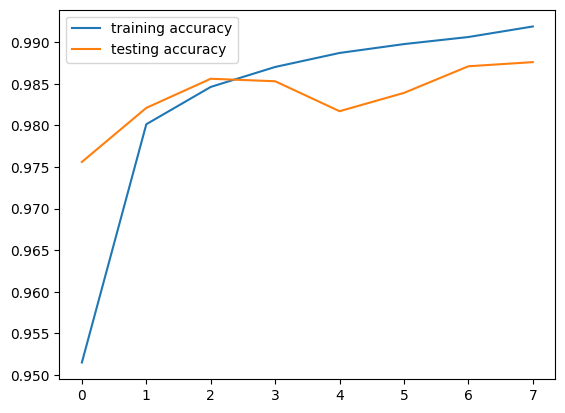

In [14]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label = 'training accuracy')
plt.plot(history.history['val_accuracy'], label = 'testing accuracy')

plt.legend()
plt.show()

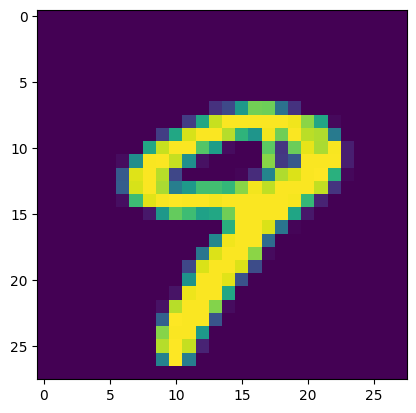

In [15]:
## checking output

plt.imshow(x_test[9])

In [18]:
print(y_pred[9])

9
